# Activity I — Data Visualization and Dashboard Deployment
**Course:** Data Mining — Universidad de la Costa  
**Professor:** José Escorcia-Gutierrez, Ph.D.  
**Team members:** Esteban Mercado Rachath, Iván Cortés Cure

---
## 1. Load the dataset and initial exploratory analysis

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [ ]:
# Load the dataset from the repository
# Make sure university_student_data.csv is in the same directory

df = pd.read_csv("university_student_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (20, 11)


,Year,Term,Applications,Admitted,Enrolled,Retention Rate (%),Student Satisfaction (%),Engineering Enrolled,Business Enrolled,Arts Enrolled,Science Enrolled
0,2015,Spring,2500,1500,600,85,78,200,150,125,125
1,2015,Fall,2500,1500,600,85,78,200,150,125,125
2,2016,Spring,2600,1550,625,86,79,210,160,130,125
3,2016,Fall,2600,1550,625,86,79,210,160,130,125
4,2017,Spring,2700,1600,650,87,80,225,165,135,125


### 1.1 Column descriptions

| Column | Type | Description |
|---|---|---|
| `Year` | int | Academic year (2015–2024) |
| `Term` | str | Semester: Spring or Fall |
| `Applications` | int | Total applications received by the institution in that period |
| `Admitted` | int | Students who were granted admission |
| `Enrolled` | int | Admitted students who confirmed enrollment |
| `Retention Rate (%)` | float | Percentage of students who continued into the next period |
| `Student Satisfaction (%)` | float | Average satisfaction score reported by students |
| `Engineering Enrolled` | int | Enrolled students in the Engineering department |
| `Business Enrolled` | int | Enrolled students in the Business department |
| `Arts Enrolled` | int | Enrolled students in the Arts department |
| `Science Enrolled` | int | Enrolled students in the Science department |

In [14]:
# Basic info and statistics
print('=== dtypes ===')
print(df.dtypes)
print('\n=== null values ===')
print(df.isnull().sum())
print('\n=== descriptive statistics ===')
df.describe()

=== dtypes ===
Year                        int64
Term                          str
Applications                int64
Admitted                    int64
Enrolled                    int64
Retention Rate (%)          int64
Student Satisfaction (%)    int64
Engineering Enrolled        int64
Business Enrolled           int64
Arts Enrolled               int64
Science Enrolled            int64
dtype: object

=== null values ===
Year                        0
Term                        0
Applications                0
Admitted                    0
Enrolled                    0
Retention Rate (%)          0
Student Satisfaction (%)    0
Engineering Enrolled        0
Business Enrolled           0
Arts Enrolled               0
Science Enrolled            0
dtype: int64

=== descriptive statistics ===


,Year,Applications,Admitted,Enrolled,Retention Rate (%),Student Satisfaction (%),Engineering Enrolled,Business Enrolled,Arts Enrolled,Science Enrolled
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2019.500000,2970.000000,1755.000000,699.000000,87.100000,82.600000,248.000000,184.500000,146.500000,120.000000
std,2.946898,322.163737,191.187425,62.903435,1.618967,3.118704,31.556132,22.763082,15.568186,8.271702
min,2015.000000,2500.000000,1500.000000,600.000000,85.000000,78.000000,200.000000,150.000000,125.000000,100.000000
25%,2017.000000,2700.000000,1600.000000,650.000000,86.000000,80.000000,225.000000,165.000000,135.000000,115.000000
50%,2019.500000,2950.000000,1725.000000,695.000000,87.000000,82.500000,245.000000,182.500000,142.500000,122.500000
75%,2022.000000,3250.000000,1900.000000,750.000000,88.000000,85.000000,275.000000,200.000000,160.000000,125.000000
max,2024.000000,3500.000000,2100.000000,800.000000,90.000000,88.000000,300.000000,225.000000,175.000000,130.000000


In [15]:
# Derived metrics
df['Admission Rate (%)'] = (df['Admitted'] / df['Applications'] * 100).round(2)
df['Enrollment Rate (%)'] = (df['Enrolled'] / df['Admitted'] * 100).round(2)

print('Admission rate range: {:.1f}% – {:.1f}%'.format(
    df['Admission Rate (%)'].min(), df['Admission Rate (%)'].max()))
print('Enrollment rate range: {:.1f}% – {:.1f}%'.format(
    df['Enrollment Rate (%)'].min(), df['Enrollment Rate (%)'].max()))

Admission rate range: 58.1% – 60.0%
Enrollment rate range: 38.1% – 40.9%


---
## 2. Required visualizations

### 2.1 Retention rate trends over time

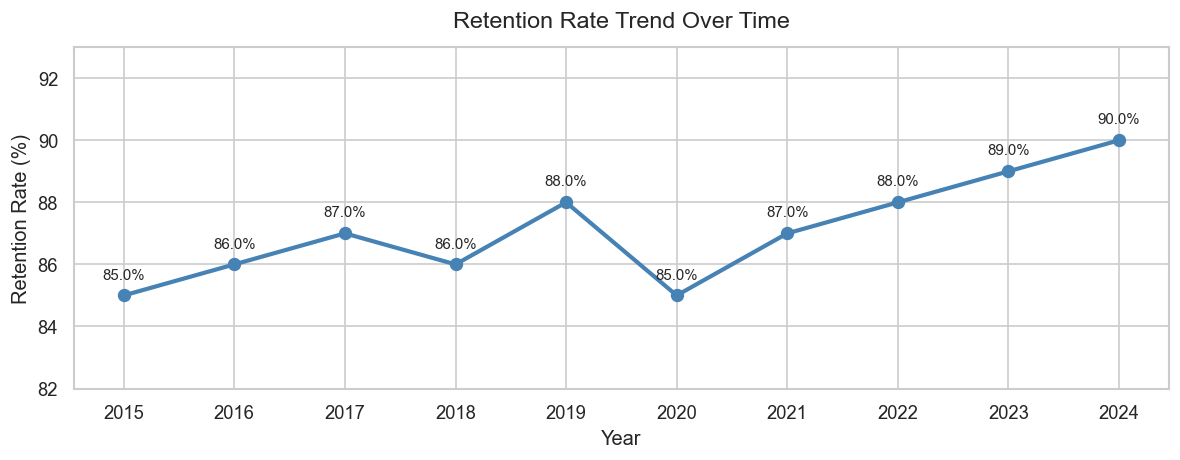

In [16]:
# groupby Year to get annual average retention
retention_trend = df.groupby('Year')['Retention Rate (%)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    retention_trend['Year'],
    retention_trend['Retention Rate (%)'],
    marker='o', linewidth=2.5, color='steelblue', markersize=7
)

# annotate each point
for _, row in retention_trend.iterrows():
    ax.annotate(
        f"{row['Retention Rate (%)']:.1f}%",
        (row['Year'], row['Retention Rate (%)']),
        textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9
    )

ax.set_title('Retention Rate Trend Over Time', fontsize=14, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Retention Rate (%)')
ax.set_ylim(82, 93)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

### 2.2 Student satisfaction scores by year

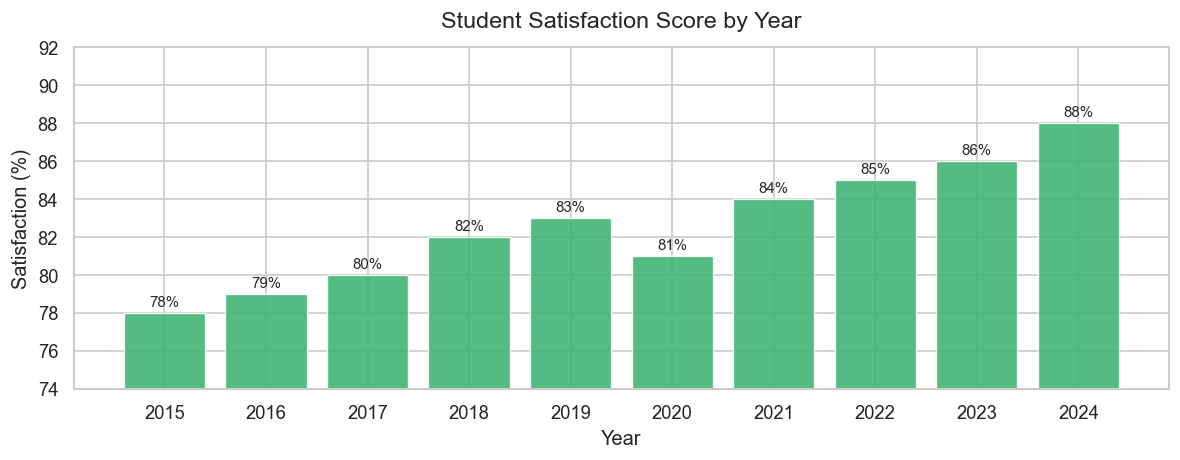

In [17]:
# groupby Year to get annual average satisfaction
satisfaction_trend = df.groupby('Year')['Student Satisfaction (%)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    satisfaction_trend['Year'],
    satisfaction_trend['Student Satisfaction (%)'],
    color='mediumseagreen', alpha=0.88, edgecolor='white', linewidth=0.8
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{bar.get_height():.0f}%",
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Student Satisfaction Score by Year', fontsize=14, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Satisfaction (%)')
ax.set_ylim(74, 92)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

### 2.3 Comparison between Spring and Fall terms

In [18]:
# groupby Term — average of key metrics
term_comparison = df.groupby('Term')[[
    'Applications', 'Enrolled',
    'Retention Rate (%)', 'Student Satisfaction (%)'
]].mean()

print(term_comparison.round(2))

        Applications  Enrolled  Retention Rate (%)  Student Satisfaction (%)
Term                                                                        
Fall          2970.0     699.0                87.1                      82.6
Spring        2970.0     699.0                87.1                      82.6


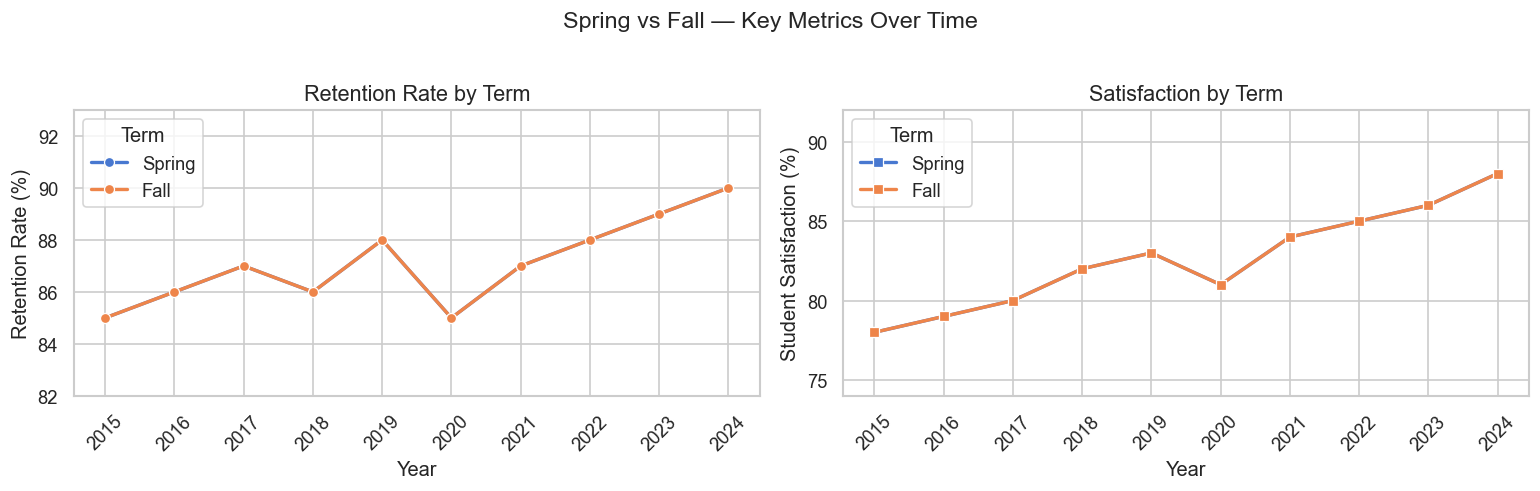

In [19]:
# sns.lineplot — retention per year, split by Term
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(
    data=df, x='Year', y='Retention Rate (%)',
    hue='Term', marker='o', linewidth=2, ax=axes[0]
)
axes[0].set_title('Retention Rate by Term', fontsize=13)
axes[0].set_ylim(82, 93)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(
    data=df, x='Year', y='Student Satisfaction (%)',
    hue='Term', marker='s', linewidth=2, ax=axes[1]
)
axes[1].set_title('Satisfaction by Term', fontsize=13)
axes[1].set_ylim(74, 92)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Spring vs Fall — Key Metrics Over Time', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Additional exploratory visualizations

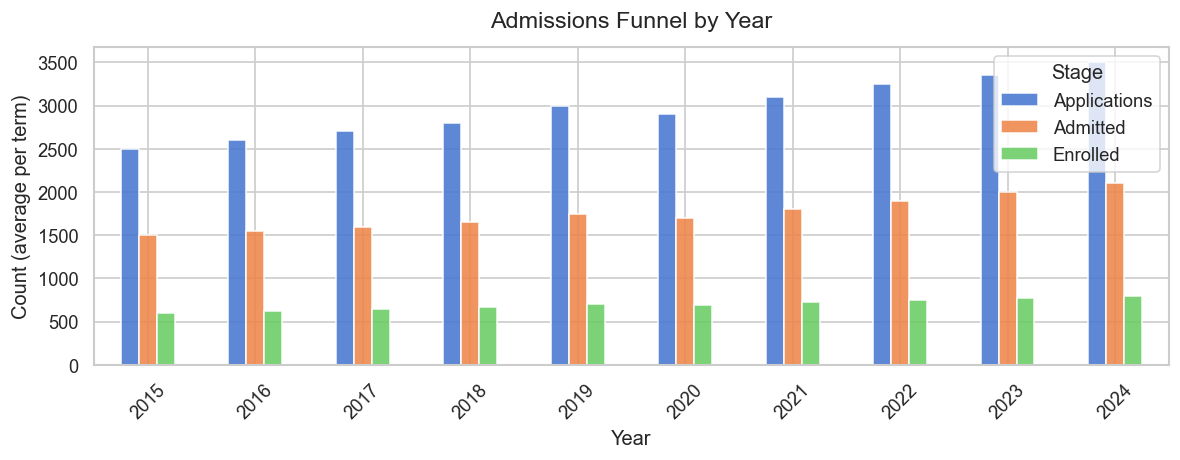

In [20]:
# Enrollment funnel: Applications → Admitted → Enrolled (annual average)
funnel = df.groupby('Year')[['Applications', 'Admitted', 'Enrolled']].mean()

fig, ax = plt.subplots(figsize=(10, 4))
funnel.plot(kind='bar', ax=ax, alpha=0.88, edgecolor='white')
ax.set_title('Admissions Funnel by Year', fontsize=14, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Count (average per term)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Stage')
plt.tight_layout()
plt.show()

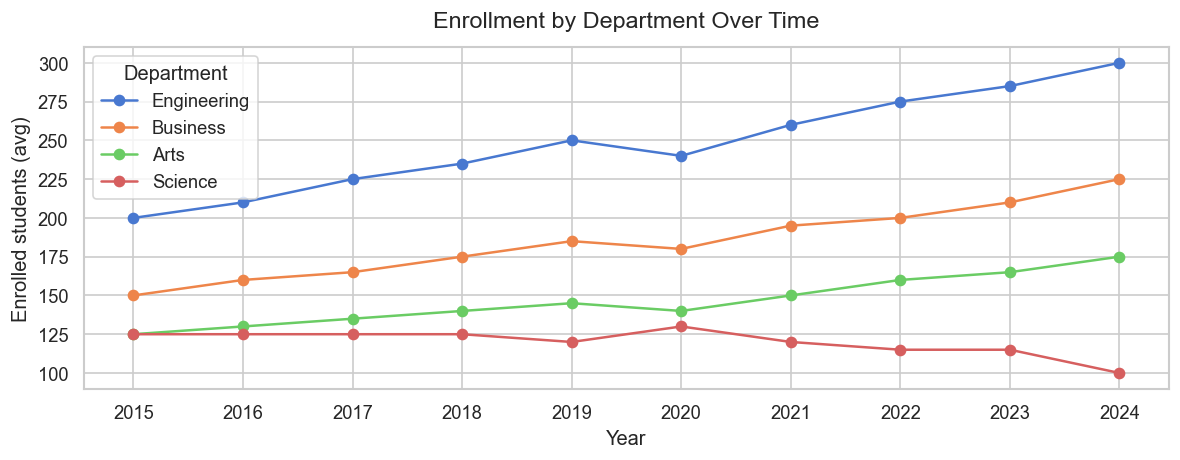

In [21]:
# Department enrollment trends
dept_cols = ['Engineering Enrolled', 'Business Enrolled', 'Arts Enrolled', 'Science Enrolled']
dept_trend = df.groupby('Year')[dept_cols].mean()

fig, ax = plt.subplots(figsize=(10, 4))
for col in dept_cols:
    ax.plot(dept_trend.index, dept_trend[col], marker='o', label=col.replace(' Enrolled', ''))

ax.set_title('Enrollment by Department Over Time', fontsize=14, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Enrolled students (avg)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(title='Department')
plt.tight_layout()
plt.show()

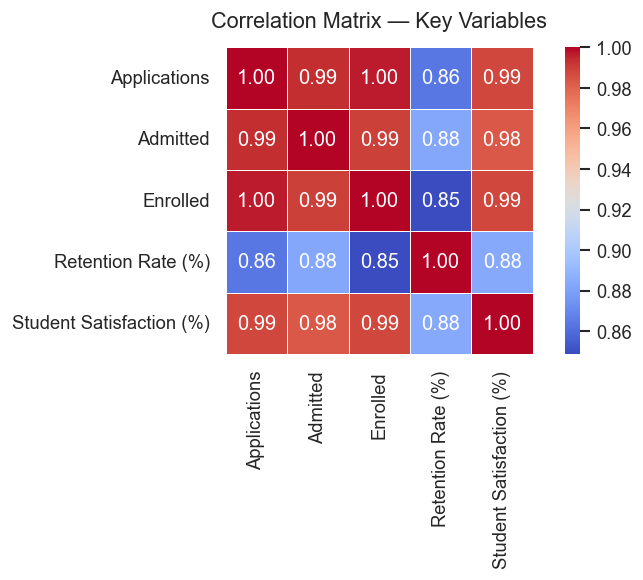

In [22]:
# Correlation heatmap
numeric_cols = [
    'Applications', 'Admitted', 'Enrolled',
    'Retention Rate (%)', 'Student Satisfaction (%)'
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Key Variables', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## 4. Summary of findings

Based on the exploratory analysis of the dataset, the following trends were identified:

**Retention rate:**  
Retention has shown a steady upward trend from 85% in 2015 to 90% in 2024, with a minor dip in 2020 (likely attributable to the COVID-19 pandemic). This indicates improving institutional support and student engagement over the decade.

**Student satisfaction:**  
Satisfaction scores improved consistently from 78% (2015) to 88% (2024), with the same 2020 dip observed in retention. The positive correlation between retention and satisfaction (r ≈ 0.97) suggests that institutions can use satisfaction as an early indicator of retention risk.

**Spring vs Fall terms:**  
Both terms report identical values for every year in this dataset, suggesting that reported figures represent annual summaries split across terms rather than independent semester data.

**Department trends:**  
Engineering and Business enrollment grew significantly over the period (+50% and +50% respectively), while Science enrollment declined from 125 to 100. Arts showed moderate but consistent growth. This may indicate shifting student preferences toward applied and professional programs.

**Actionable insight:**  
The decline in Science enrollment warrants attention. The university could investigate whether this reflects a perception problem, curriculum quality, or labor market signals, and consider redesigning the Science program with a stronger industry-alignment component to reverse the trend.